# Lecture 4: Linear classification, softmax, and cross-entropy

This notebook follows the board lecture section by section: each **BOARD** block restates what was derived on the board, and each **QUESTION BEFORE RUNNING** asks for a prediction before the next cell.

[Open in Google Colab](https://colab.research.google.com/github/DrFarrukh/teaching/blob/main/courses/artificial-neural-networks/lectures/lecture-04/notebook.ipynb). Select **Runtime → Run all**. The examples use synthetic data and need no file uploads.

In [1]:
# Google Colab includes these packages in its standard runtime.
# Uncomment this line only if a package is missing:
# %pip install torch numpy matplotlib

# SE-801 — Lecture 4
## Linear classification, softmax, and cross-entropy

**Story:** Our calibration learner returned a real number. Suppose the target
now names one of three machine states: **normal**, **drift**, or **fault**.
How must the model, loss, and evaluation change?

**Conventions:** Features `X:[N,2]`, mathematical weight `W:[2,3]`, bias
`b:[3]`, logits `O:[N,3]`, class-index targets `[N]`. The three classes are
indices 0, 1, 2. `nn.CrossEntropyLoss` receives **logits**, never
probabilities. All reported losses are means per example. The held-out test
split is generated below but stays unscored until RUN 14. No GPU, dataset
download, or d2l package is required.

In [2]:
%matplotlib inline
# RUN 0 — Setup
import math
import os
from pathlib import Path
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.set_num_threads(1)
DTYPE = torch.float64
SEED = 41
CLASSES = ("normal", "drift", "fault")
COLORS = ["#2F75B5", "#C74B50", "#B57A12"]
plt.rcParams.update({"figure.figsize": (10.5, 5.4), "font.size": 13,
                     "axes.titlesize": 17, "axes.labelsize": 14,
                     "legend.fontsize": 11, "axes.grid": True,
                     "grid.alpha": 0.2, "figure.dpi": 110})
torch.manual_seed(SEED)
np.random.seed(SEED)


def finish(name):
    plt.tight_layout()
    # Export is enabled only by the build script, not by ordinary class use.
    if os.environ.get("ANN_LEC4_FIGURES"):
        folder = Path(os.environ["ANN_LEC4_FIGURES"])
        folder.mkdir(parents=True, exist_ok=True)
        plt.savefig(folder / f"{name}.png", dpi=160, bbox_inches="tight")
    if plt.get_backend().lower() != "agg":
        plt.show()
    plt.close()


def as_index_map(labels):
    """Map string class labels to consecutive integer indices."""
    order = sorted(set(labels))
    lookup = {name: k for k, name in enumerate(order)}
    return lookup, np.array([lookup[name] for name in labels], dtype=np.int64)


print("NumPy:", np.__version__, "PyTorch:", torch.__version__)
print("Classes:", CLASSES, "| CPU / float64 / mean cross-entropy / logits in, indices out")

NumPy: 2.5.3 PyTorch: 2.14.0+cu130
Classes: ('normal', 'drift', 'fault') | CPU / float64 / mean cross-entropy / logits in, indices out


## 1. A real-valued output is not a label

**BOARD:** Lecture 1 wrote `prediction → loss → gradient → update`. Lecture 3
separated fitted-sample evidence from fresh-data evidence. If `y=2` names the
third category, then `(prediction−2)²` treats “fault” as twice “drift” and
penalizes a correct prediction of “drift” (1) more than a correct “normal”
(0). The numeric codes are arbitrary.

The classifier instead produces one **logit** per class:

$$O=XW+b,\qquad X:[N,2],\; W:[2,3],\; b:[3],\; O:[N,3].$$

Logits are unrestricted real scores. The decision is
`argmax_k o_k`. Softmax turns the scores into probabilities afterward; the
decision does not require it.

**QUESTION BEFORE RUNNING:** For logits `[2, 1, −1]`, which class wins? Do the
three logits sum to one? What happens to the decision if we add `10` to all
three scores?

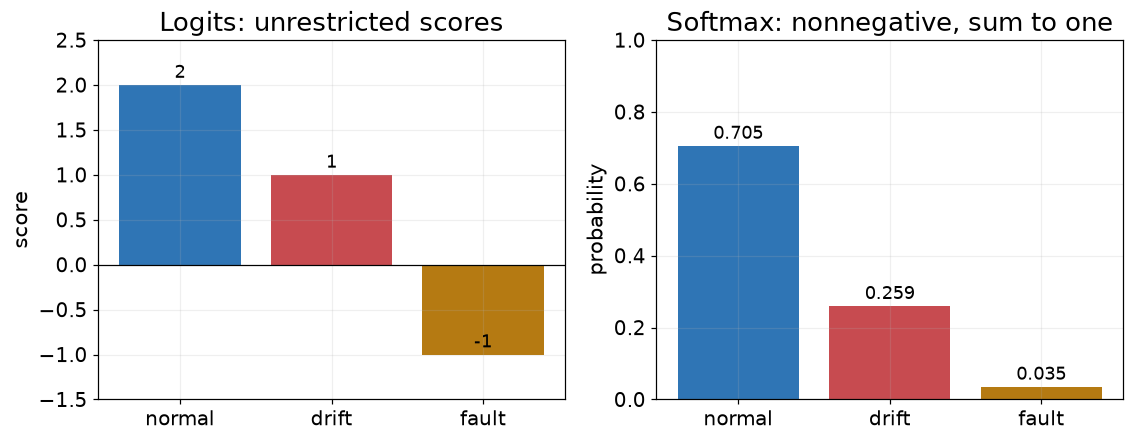

logits: [2.0, 1.0, -1.0] | sum is not one: 2.0
softmax: [0.7054 0.2595 0.0351] | rows sum to one
predicted class: normal
Adding a constant to every logit leaves softmax and the decision unchanged.


In [3]:
# RUN 1 — Logits score classes; argmax decides
logits_hand = torch.tensor([[2.0, 1.0, -1.0]], dtype=DTYPE)
prob_hand = torch.softmax(logits_hand, dim=1)
shifted_hand = torch.softmax(logits_hand + 10.0, dim=1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].bar(CLASSES, logits_hand[0].tolist(), color=COLORS)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(title="Logits: unrestricted scores", ylabel="score", ylim=(-1.5, 2.5))
for k, value in enumerate(logits_hand[0].tolist()):
    axes[0].text(k, value + 0.08, f"{value:g}", ha="center", fontsize=12)
axes[1].bar(CLASSES, prob_hand[0].tolist(), color=COLORS)
axes[1].set(title="Softmax: nonnegative, sum to one", ylabel="probability", ylim=(0, 1))
for k, value in enumerate(prob_hand[0].tolist()):
    axes[1].text(k, value + 0.02, f"{value:.3f}", ha="center", fontsize=12)
finish("01_scores_to_probabilities")

print("logits:", logits_hand[0].tolist(), "| sum is not one:", logits_hand.sum().item())
print("softmax:", np.round(prob_hand[0].numpy(), 4), "| rows sum to one")
print("predicted class:", CLASSES[logits_hand.argmax(1).item()])
assert torch.allclose(prob_hand, shifted_hand, atol=1e-12)
assert torch.allclose(prob_hand.sum(1), torch.ones(1, dtype=DTYPE))
print("Adding a constant to every logit leaves softmax and the decision unchanged.")

**QUESTION BEFORE RUNNING:** A model predicts `1.2` for an example whose true
label is `2`. Which numeric penalty does squared error assign? Why is that
penalty scientifically meaningless for a category?

## 2. The two-class bridge: sigmoid

**BOARD:** For one binary logit `z`, the class-1 probability is
$\sigma(z)=1/(1+e^{-z})$ and class 0 receives $1-\sigma(z)$.
Thresholding probability at `0.5` is identical to thresholding `z` at `0`.
For two logits $o_0,o_1$, dividing the class-1 softmax probability by
$e^{o_1}$ gives

$$p_1=\frac{e^{o_1}}{e^{o_0}+e^{o_1}}=\frac{1}{1+e^{o_0-o_1}}
=\sigma(o_1-o_0).$$

Only the **logit difference** controls a binary decision.

**QUESTION BEFORE RUNNING:** Predict $\sigma(0)$, and decide whether $\sigma(2)$
is above or below `0.5`. Does the two-logit softmax agree with the sigmoid
of the difference?

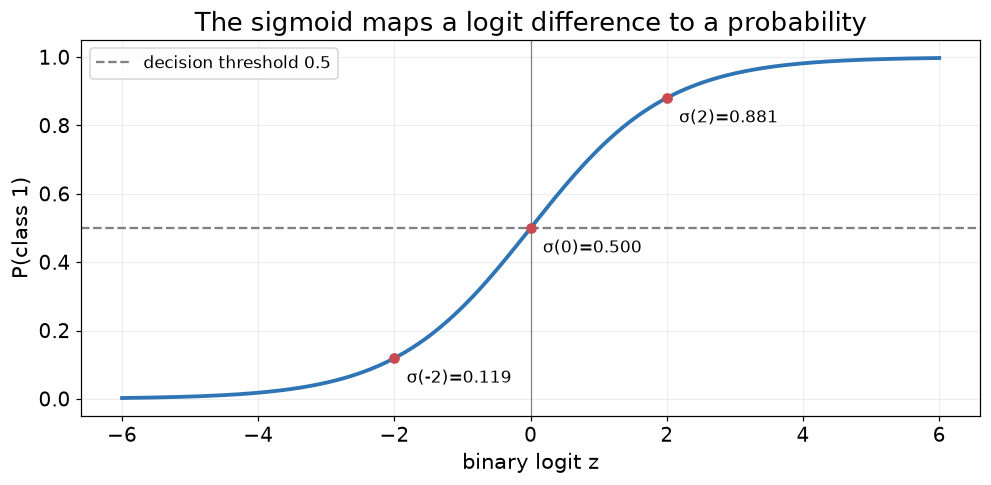

sigmoid(-2, 0, 2): [0.1192 0.5    0.8808]
two-logit softmax p1: 0.880797 | sigmoid(o1-o0): 0.880797


In [4]:
# RUN 2 — Sigmoid and the two-logit equivalence
z = torch.linspace(-6, 6, 241, dtype=DTYPE)
sigmoid = torch.sigmoid(z)
pair = torch.tensor([[0.0, 2.0]], dtype=DTYPE)
pair_p1 = torch.softmax(pair, dim=1)[0, 1]

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(z.numpy(), sigmoid.numpy(), color=COLORS[0], lw=2.5)
ax.axhline(0.5, color="gray", ls="--", label="decision threshold 0.5")
ax.axvline(0.0, color="gray", lw=0.8)
for point in (-2.0, 0.0, 2.0):
    value = float(torch.sigmoid(torch.tensor(point, dtype=DTYPE)))
    ax.scatter([point], [value], color=COLORS[1], zorder=3)
    ax.annotate(f"σ({point:g})={value:.3f}", (point, value),
                textcoords="offset points", xytext=(8, -16), fontsize=11)
ax.set(title="The sigmoid maps a logit difference to a probability",
       xlabel="binary logit z", ylabel="P(class 1)", ylim=(-0.05, 1.05))
ax.legend(loc="upper left")
finish("02_sigmoid_bridge")

print("sigmoid(-2, 0, 2):", np.round(torch.sigmoid(torch.tensor([-2., 0., 2.], dtype=DTYPE)).numpy(), 4))
print("two-logit softmax p1:", round(pair_p1.item(), 6),
      "| sigmoid(o1-o0):", round(torch.sigmoid(pair[0, 1] - pair[0, 0]).item(), 6))
assert torch.allclose(pair_p1, torch.sigmoid(pair[0, 1] - pair[0, 0]), atol=1e-12)

## 3. Softmax turns many scores into one distribution

**BOARD:** For logits $o_1,\dots,o_C$,

$$p_k=\frac{e^{o_k}}{\sum_{j=1}^{C}e^{o_j}},\qquad p_k>0,\qquad \sum_k p_k=1.$$

Every row of `[N,C]` logits becomes a probability distribution over classes.
A target may be a **class index** $y\in\{0,\dots,C-1\}$ or its **one-hot**
row $q$ with $q_y=1$ and all other entries zero. Ordinary
`nn.CrossEntropyLoss` requires the index form as a `long` tensor of shape
`[N]`; the one-hot form is used in today's derivations and scratch code.

**HAND CALCULATION:** For logits `[ln 2, ln 1, ln 1]`, calculate the three
probabilities. Write the one-hot target for class 0.

In [5]:
# RUN 3 — Softmax, one-hot targets, and shape checks
o_hand = torch.log(torch.tensor([[2.0, 1.0, 1.0]], dtype=DTYPE))
p_hand = torch.softmax(o_hand, dim=1)
y_index = torch.tensor([0], dtype=torch.long)
y_one_hot = torch.nn.functional.one_hot(y_index, num_classes=3).to(DTYPE)
print("logits:", o_hand[0].tolist())
print("probabilities:", np.round(p_hand[0].numpy(), 6), "| row sum:", p_hand.sum(1).item())
print("class index:", y_index.tolist(), "| one-hot row:", y_one_hot[0].tolist())
assert torch.allclose(p_hand, torch.tensor([[0.5, 0.25, 0.25]], dtype=DTYPE))
assert y_index.shape == (1,) and y_one_hot.shape == (1, 3)
print("Index and one-hot identify the same class; only their encodings differ.")

logits: [0.6931471805599453, 0.0, 0.0]
probabilities: [0.5  0.25 0.25] | row sum: 1.0
class index: [0] | one-hot row: [1.0, 0.0, 0.0]
Index and one-hot identify the same class; only their encodings differ.


## 4. Negative log-likelihood and cross-entropy

**BOARD:** For one example, the loss is the negative log of the probability
assigned to the true class:

$$\ell=-\ln p_y=-\sum_k q_k\ln p_k .$$

A confident correct prediction contributes little; a confident wrong
prediction contributes a lot. Cross-entropy distinguishes two rows that
`argmax` labels identically but that assign different probability to the
true class. That is why we do not optimize accuracy directly: accuracy is
piecewise constant in the parameters, while `−ln p_y` supplies a useful
gradient.

**QUESTION BEFORE RUNNING:** Which is larger, `−ln(0.5)` or `−ln(0.01)`? Compute
both. What loss does the true-class probability `1.0` give?

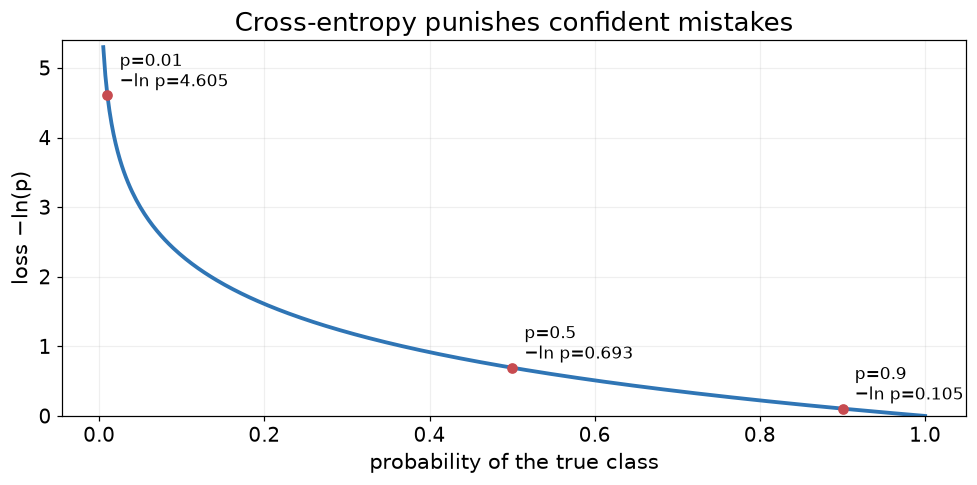

index NLL: 0.693147 | one-hot cross-entropy: 0.693147
−ln(0.5) = 0.6931 | −ln(0.01) = 4.6052


In [6]:
# RUN 4 — The same loss from a class index and from one-hot rows
loss_index = -torch.log(p_hand[0, y_index[0]])
loss_one_hot = -(y_one_hot * torch.log(p_hand)).sum(dim=1).mean()
p_grid = np.linspace(0.005, 1.0, 400)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(p_grid, -np.log(p_grid), color=COLORS[0], lw=2.5)
for p_true, label in ((0.01, "confident error"), (0.5, "uncertain"), (0.9, "confident")):
    ax.scatter([p_true], [-math.log(p_true)], color=COLORS[1], zorder=3)
    ax.annotate(f"p={p_true:g}\n−ln p={-math.log(p_true):.3f}", (p_true, -math.log(p_true)),
                textcoords="offset points", xytext=(8, 6), fontsize=11)
ax.set(title="Cross-entropy punishes confident mistakes", xlabel="probability of the true class",
       ylabel="loss −ln(p)", ylim=(0, 5.4))
finish("03_nll_curve")

print("index NLL:", round(loss_index.item(), 6),
      "| one-hot cross-entropy:", round(loss_one_hot.item(), 6))
print("−ln(0.5) =", round(math.log(2), 4), "| −ln(0.01) =", round(-math.log(0.01), 4))
assert torch.allclose(loss_index, loss_one_hot, atol=1e-12)

## 5. Numerical stability: subtract the row maximum

**BOARD:** `exp(1000)` overflows ordinary floating point, yet the softmax
probabilities of `[1000, 999, 995]` are perfectly well defined. Subtracting
the row maximum `m=max_j o_j` from every logit leaves the probabilities
unchanged and keeps the exponentials in `(0, 1]`. Combining that identity
with the logarithm gives the stable loss

$$\ell=\ln\!\Big(\sum_j e^{o_j}\Big)-o_y
=m+\ln\!\Big(\sum_j e^{o_j-m}\Big)-o_y
=\mathrm{logsumexp}(o)-o_y .$$

`torch.logsumexp` and `nn.CrossEntropyLoss` use stable internal forms.
A naive `exp(logits)/sum(exp(logits))` can produce `inf/inf = NaN`.

**QUESTION BEFORE RUNNING:** Will the naive softmax of `[1000, 999, 995]`
produce numbers, `NaN`, or zeros? Which quantity is safe to compute for the
same row?

In [7]:
# RUN 5 — A naive calculation overflows; shifted and framework forms agree
large = torch.tensor([[1000.0, 999.0, 995.0]], dtype=DTYPE)
large_target = torch.tensor([0], dtype=torch.long)
with np.errstate(over="ignore", invalid="ignore"):
    naive = large.exp() / large.exp().sum(dim=1, keepdim=True)
shifted = large - large.max(dim=1, keepdim=True).values
stable_p = shifted.exp() / shifted.exp().sum(dim=1, keepdim=True)
stable_ce = torch.logsumexp(large, dim=1) - large.gather(1, large_target[:, None]).squeeze(1)
framework_ce = nn.CrossEntropyLoss()(large, large_target)
print("naive softmax:", naive.numpy().tolist())
print("shifted logits:", shifted[0].tolist(), "| stable p:", np.round(stable_p[0].numpy(), 4))
print("stable CE:", round(stable_ce.item(), 6), "| framework CE:", round(framework_ce.item(), 6))
assert not torch.isfinite(naive).all()
assert torch.allclose(stable_ce, framework_ce, atol=1e-12)

naive softmax: [[nan, nan, nan]]
shifted logits: [0.0, -1.0, -5.0] | stable p: [0.7275 0.2676 0.0049]
stable CE: 0.318175 | framework CE: 0.318175


## 6. A scratch loss and its framework equivalent

**BOARD pseudocode:** keep the logits in the computation graph, gather the
true-class logit per row, and average the stable per-example losses:

```text
chosen = logits.gather(1, targets[:, None]).squeeze(1)   # [N]
loss   = mean(logsumexp(logits, dim=1) − chosen)          # scalar
```

**QUESTION BEFORE RUNNING:** Which axis represents classes? What shape does one
per-example loss have, and what shape is the returned mean?

In [8]:
# RUN 6 — Stable tensor implementation and independent framework check
def scratch_cross_entropy(logits, targets):
    assert logits.ndim == 2 and targets.ndim == 1
    assert logits.shape[0] == targets.shape[0]
    chosen = logits.gather(1, targets[:, None]).squeeze(1)
    return (torch.logsumexp(logits, dim=1) - chosen).mean()


trial = torch.tensor([[2.0, 1.0, -1.0], [-0.3, 0.2, 1.2]], dtype=DTYPE, requires_grad=True)
trial_targets = torch.tensor([0, 2], dtype=torch.long)
scratch_loss = scratch_cross_entropy(trial, trial_targets)
torch_loss = nn.CrossEntropyLoss()(trial, trial_targets)
print("scratch:", round(scratch_loss.item(), 6), "| nn.CrossEntropyLoss:", round(torch_loss.item(), 6))
assert torch.allclose(scratch_loss, torch_loss, atol=1e-12)
print("Our tensor implementation is differentiable and matches the framework.")

scratch: 0.406691 | nn.CrossEntropyLoss: 0.406691
Our tensor implementation is differentiable and matches the framework.


# Break

Keep `logits → softmax → true-class probability → −ln` and the stable
`logsumexp` form in view. After the break: predict the **sign** of the
gradient for the true class before any derivation.

## 7. The gradient is probability minus target

**BOARD:** Start from $\ell=\mathrm{logsumexp}(o)-o_y$. Since
$\partial\,\mathrm{logsumexp}(o)/\partial o_k=p_k$ and
$\partial o_y/\partial o_k=\mathbb{1}[k=y]$,

$$\frac{\partial \ell}{\partial o_k}=p_k-\mathbb{1}[k=y].$$

For a batch mean, divide each example's gradient by `N`: the logit gradient
is `(p − one_hot)/N`. The gradient is positive for classes that received
too much probability mass and negative for the true class (unless
`p_y = 1`). One gradient step therefore raises the true-class logit relative
to its competitors.

**HAND CALCULATION:** With `p = [0.5, 0.25, 0.25]` and true class 0, write
the three logit gradients of one example. Do they sum to zero?

In [9]:
# RUN 7 — Verify the derived gradient against autograd
one = o_hand.detach().clone().requires_grad_(True)
one_loss = scratch_cross_entropy(one, y_index)
one_loss.backward()
expected_grad = p_hand - y_one_hot
print("autograd gradient:", np.round(one.grad[0].numpy(), 4))
print("p minus one-hot:  ", np.round(expected_grad[0].numpy(), 4))
assert torch.allclose(one.grad, expected_grad, atol=1e-12)
assert abs(one.grad.sum().item()) < 1e-12
print("The gradient entries sum to zero and match the derivation exactly.")

autograd gradient: [-0.5   0.25  0.25]
p minus one-hot:   [-0.5   0.25  0.25]
The gradient entries sum to zero and match the derivation exactly.


## 8. A compact three-state dataset

**BOARD:** Two unitless features from a vibration window imitate a simple
machine-state problem. Three overlapping Gaussian clusters represent
**normal**, **drift**, and **fault**. Training has 80 examples per class;
validation and test have 30 per class each. The three draws use separate
seeds, so validation genuinely measures unseen rows.

Feature standardization uses the **training** means and standard deviations
and reuses them for validation and test. The test split is generated now but
remains unscored and unprinted until RUN 14.

**QUESTION BEFORE RUNNING:** May the validation or test rows contribute to the
feature means and standard deviations? Which split may select an epoch?

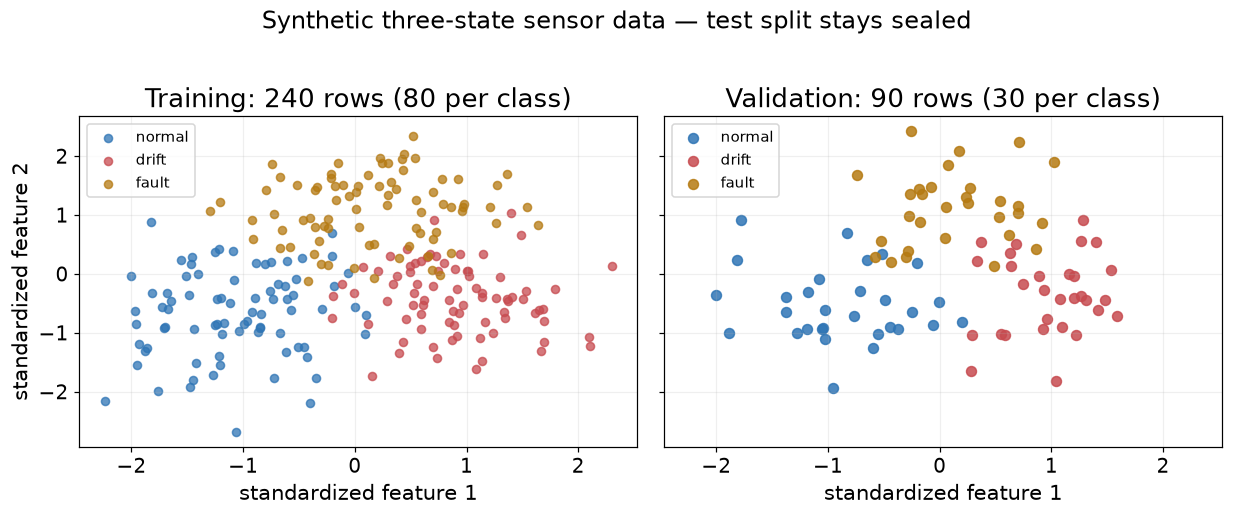

train: (240, 2) | validation: (90, 2) | sealed test rows: 90
training class counts: [80, 80, 80]
training feature means: [-0.0, 0.0]


In [10]:
# RUN 8 — Freeze three independent splits and train-only scaling
centers = np.array([[-1.5, -0.6], [1.3, -0.4], [0.1, 1.4]])
cluster_scale = 0.75


def make_split(seed, count_per_class):
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    for k, count in enumerate(count_per_class):
        xs.append(rng.normal(loc=centers[k], scale=cluster_scale, size=(count, 2)))
        ys.append(np.full(count, k, dtype=np.int64))
    X = np.vstack(xs)
    y = np.concatenate(ys)
    order = rng.permutation(len(y))
    return torch.tensor(X[order], dtype=DTYPE), torch.tensor(y[order], dtype=torch.long)


X_train_raw, y_train = make_split(101, [80, 80, 80])
X_val_raw, y_val = make_split(104, [30, 30, 30])
_X_test_raw, _y_test = make_split(103, [30, 30, 30])
train_mean = X_train_raw.mean(dim=0, keepdim=True)
train_std = X_train_raw.std(dim=0, correction=0, keepdim=True)
X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6), sharex=True, sharey=True)
for k, (name, color) in enumerate(zip(CLASSES, COLORS)):
    axes[0].scatter(X_train[y_train == k, 0], X_train[y_train == k, 1],
                    s=28, alpha=0.75, color=color, label=name)
    axes[1].scatter(X_val[y_val == k, 0], X_val[y_val == k, 1],
                    s=42, alpha=0.85, color=color, label=name)
axes[0].set_title("Training: 240 rows (80 per class)")
axes[1].set_title("Validation: 90 rows (30 per class)")
for ax in axes:
    ax.set_xlabel("standardized feature 1")
    ax.legend(loc="upper left", fontsize=10)
axes[0].set_ylabel("standardized feature 2")
fig.suptitle("Synthetic three-state sensor data — test split stays sealed", y=1.02)
finish("04_dataset_splits")

print("train:", tuple(X_train.shape), "| validation:", tuple(X_val.shape),
      "| sealed test rows:", len(_y_test))
print("training class counts:", torch.bincount(y_train, minlength=3).tolist())
print("training feature means:", np.round(X_train.mean(0).numpy(), 8).tolist())
assert X_train.shape == (240, 2) and X_val.shape == (90, 2) and len(_y_test) == 90
assert torch.allclose(X_train.mean(0), torch.zeros(2, dtype=DTYPE), atol=1e-12)

## 9. Train, validate, and select a checkpoint

**BOARD:** The model is one affine map `nn.Linear(2, 3)` with PyTorch's
stored weight shape `[3, 2]` (the transpose of the mathematical `W:[2,3]`).
The loop shuffles training rows, zeros the gradients, computes **raw
logits**, applies mean cross-entropy, backpropagates, and steps. After each
epoch it switches to evaluation mode and measures the same loss and accuracy
on training and validation rows without gradients. The epoch with the lowest
validation cross-entropy is retained. The test set never participates.

**QUESTION BEFORE RUNNING:** Is `nn.CrossEntropyLoss(softmax(logits), y)` the
same objective? Which split chooses the checkpoint, and which reports the
frozen model?

In [11]:
# RUN 9 — Complete CPU training loop with validation checkpoint selection
EPOCHS = 150
BATCH_SIZE = 32
LEARNING_RATE = 0.3
torch.manual_seed(SEED)
model = nn.Linear(2, 3).to(DTYPE)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
shuffle_rng = torch.Generator().manual_seed(SEED)
history = []
best_val = float("inf")
best_epoch = None
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    order = torch.randperm(len(y_train), generator=shuffle_rng)
    for ids in order.split(BATCH_SIZE):
        optimizer.zero_grad()
        logits = model(X_train[ids])
        loss = criterion(logits, y_train[ids])
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        train_logits = model(X_train)
        val_logits = model(X_val)
        train_ce = criterion(train_logits, y_train).item()
        val_ce = criterion(val_logits, y_val).item()
        train_acc = (train_logits.argmax(1) == y_train).to(DTYPE).mean().item()
        val_acc = (val_logits.argmax(1) == y_val).to(DTYPE).mean().item()
    history.append((epoch, train_ce, val_ce, train_acc, val_acc))
    if val_ce < best_val:
        best_val = val_ce
        best_epoch = epoch
        best_state = {key: value.detach().clone() for key, value in model.state_dict().items()}

model.load_state_dict(best_state)
print("selected epoch:", best_epoch, "of", EPOCHS, "| validation CE:", round(best_val, 4))
print("final-epoch train/validation accuracy:", round(train_acc, 3), round(val_acc, 3))
assert best_state is not None and np.isfinite(np.asarray(history)).all()
assert 1 <= best_epoch <= EPOCHS

selected epoch: 141 of 150 | validation CE: 0.2198
final-epoch train/validation accuracy: 0.908 0.867


**QUESTION BEFORE RUNNING:** Does falling training loss guarantee falling
validation loss? Must the selected epoch be the final one? Could a small
validation set make the selection noisy?

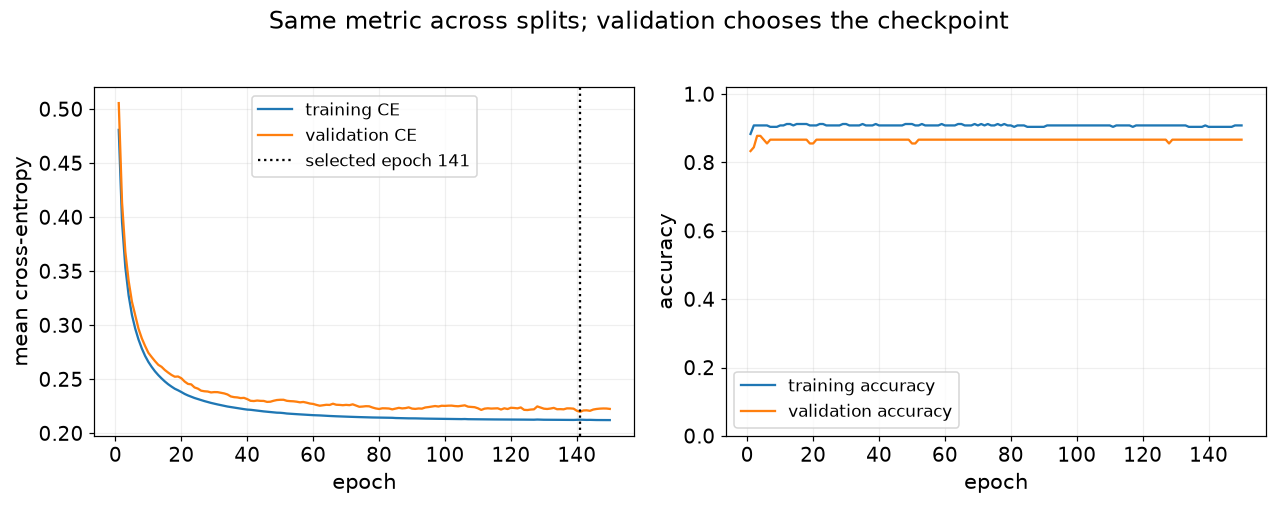

training CE at selected epoch: 0.2126
validation CE at selected epoch: 0.2198


In [12]:
# RUN 10 — Inspect learning curves and the selected checkpoint
h = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
axes[0].plot(h[:, 0], h[:, 1], label="training CE")
axes[0].plot(h[:, 0], h[:, 2], label="validation CE")
axes[0].axvline(best_epoch, color="black", ls=":", label=f"selected epoch {best_epoch}")
axes[0].set(xlabel="epoch", ylabel="mean cross-entropy")
axes[0].legend()
axes[1].plot(h[:, 0], h[:, 3], label="training accuracy")
axes[1].plot(h[:, 0], h[:, 4], label="validation accuracy")
axes[1].set(xlabel="epoch", ylabel="accuracy", ylim=(0, 1.02))
axes[1].legend()
fig.suptitle("Same metric across splits; validation chooses the checkpoint", y=1.02)
finish("05_training_curves")

print("training CE at selected epoch:", round(h[best_epoch - 1, 1], 4))
print("validation CE at selected epoch:", round(h[best_epoch - 1, 2], 4))
assert h[best_epoch - 1, 2] <= h[:, 2].min() + 1e-12

## 10. Probabilities, argmax, and a baseline

**BOARD:** At inference, apply softmax to logits only when probabilities are
needed. `argmax` of logits and of probabilities agrees. Compare the
classifier with a **training-majority baseline**: the class most frequent in
training. On our balanced training set the classes tie, so a fixed tie rule
selects class 0; on the balanced validation set that baseline reaches
`30/90 = 1/3`. A baseline tells us whether the model improves on a trivial
rule on this sample.

**QUESTION BEFORE RUNNING:** Can two rows share a predicted label but have
different cross-entropy? Is a single predicted probability of `0.8`
evidence that the model is calibrated?

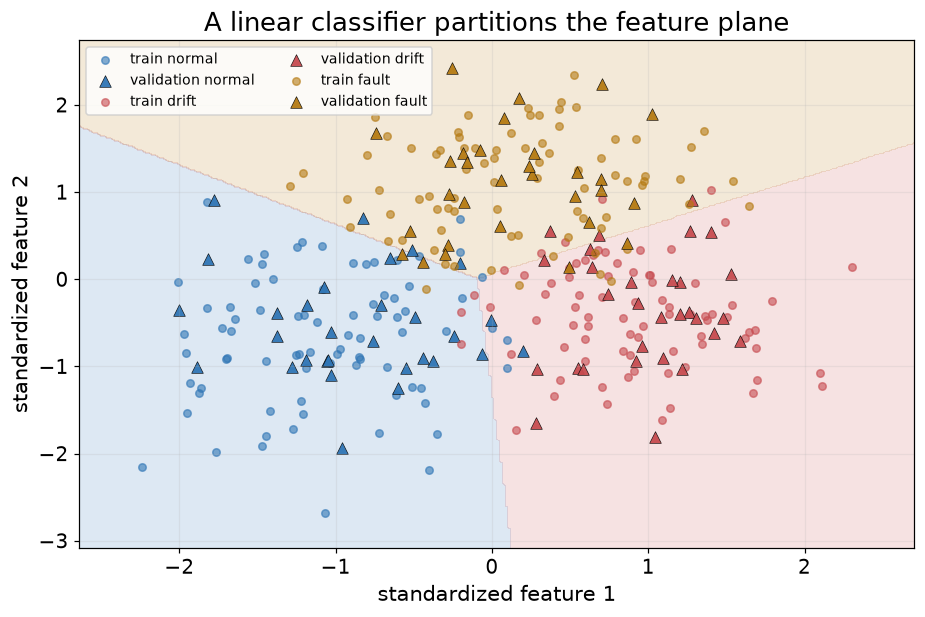

first three probability rows:
 [[0.002 0.998 0.   ]
 [0.001 0.005 0.994]
 [0.178 0.061 0.761]]
classifier validation accuracy: 0.867
majority baseline validation accuracy: 0.333


In [13]:
# RUN 11 — Validation probabilities, the decision regions, and a baseline
model.eval()
with torch.no_grad():
    val_logits = model(X_val)
    val_prob = torch.softmax(val_logits, dim=1)
    val_pred = val_logits.argmax(1)
majority_class = int(torch.bincount(y_train, minlength=3).argmax())
baseline_pred = torch.full_like(y_val, majority_class)

grid_x = torch.linspace(X_train[:, 0].min() - 0.4, X_train[:, 0].max() + 0.4, 300, dtype=DTYPE)
grid_y = torch.linspace(X_train[:, 1].min() - 0.4, X_train[:, 1].max() + 0.4, 300, dtype=DTYPE)
grid_xx, grid_yy = torch.meshgrid(grid_x, grid_y, indexing="xy")
grid_points = torch.stack([grid_xx.reshape(-1), grid_yy.reshape(-1)], dim=1)
with torch.no_grad():
    grid_class = model(grid_points).argmax(1).reshape(grid_xx.shape)

fig, ax = plt.subplots(figsize=(8.6, 5.8))
ax.contourf(grid_xx.numpy(), grid_yy.numpy(), grid_class.numpy(),
            levels=[-0.5, 0.5, 1.5, 2.5], colors=COLORS, alpha=0.16)
for k, (name, color) in enumerate(zip(CLASSES, COLORS)):
    ax.scatter(X_train[y_train == k, 0], X_train[y_train == k, 1], s=24, color=color,
               alpha=0.6, label=f"train {name}")
    ax.scatter(X_val[y_val == k, 0], X_val[y_val == k, 1], s=58, color=color, marker="^",
               edgecolor="black", linewidth=0.4, alpha=0.95, label=f"validation {name}")
ax.set(title="A linear classifier partitions the feature plane",
       xlabel="standardized feature 1", ylabel="standardized feature 2")
ax.legend(loc="upper left", fontsize=9, ncol=2)
finish("06_decision_regions")

val_accuracy = (val_pred == y_val).to(DTYPE).mean().item()
baseline_accuracy = (baseline_pred == y_val).to(DTYPE).mean().item()
print("first three probability rows:\n", np.round(val_prob[:3].numpy(), 3))
print("classifier validation accuracy:", round(val_accuracy, 3))
print("majority baseline validation accuracy:", round(baseline_accuracy, 3))
assert torch.allclose(val_prob.sum(1), torch.ones(len(val_prob), dtype=DTYPE), atol=1e-12)
assert torch.equal(val_pred, val_prob.argmax(1))
assert 0.80 <= val_accuracy <= 0.95

## 11. Confusion matrix and class-sensitive metrics

**BOARD:** Rows are **true** classes; columns are **predicted** classes. For
class `k`, with `TP=C_kk`, `FN=row sum−TP`, `FP=column sum−TP`:

$$\mathrm{precision}=\frac{TP}{TP+FP},\qquad
\mathrm{recall}=\frac{TP}{TP+FN},\qquad
F_1=\frac{2PR}{P+R}.$$

Balanced accuracy averages the **recalls**; macro F1 averages the class F1
values. In this teaching example a zero denominator sets that metric to zero,
and we report that convention. Accuracy alone can hide a class the model
never predicts.

**HAND CALCULATION:** From the displayed validation matrix, compute the
recall of the “fault” class by hand and compare it with the printed value.

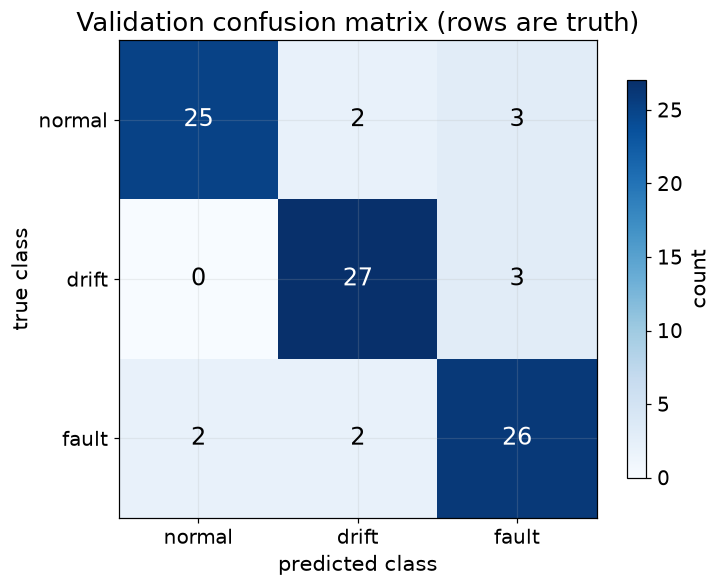

validation confusion matrix (true rows, predicted columns):
 [[25  2  3]
 [ 0 27  3]
 [ 2  2 26]]
accuracy: 0.8667 | balanced accuracy: 0.8667 | macro F1: 0.867
normal: precision=0.926 recall=0.833 F1=0.877 support=30
 drift: precision=0.871 recall=0.900 F1=0.885 support=30
 fault: precision=0.812 recall=0.867 F1=0.839 support=30


In [14]:
# RUN 12 — Metrics implemented from class indices
def confusion_matrix(y_true, y_pred, classes=3):
    cm = torch.zeros((classes, classes), dtype=torch.int64)
    for truth, prediction in zip(y_true.tolist(), y_pred.tolist()):
        cm[truth, prediction] += 1
    return cm


def class_metrics(cm):
    a = cm.to(DTYPE)
    tp = a.diag()
    support = a.sum(1)
    predicted = a.sum(0)
    precision = torch.where(predicted > 0, tp / predicted.clamp_min(1), torch.zeros_like(tp))
    recall = torch.where(support > 0, tp / support.clamp_min(1), torch.zeros_like(tp))
    f1 = torch.where(precision + recall > 0,
                     2 * precision * recall / (precision + recall).clamp_min(1e-12),
                     torch.zeros_like(tp))
    return {"accuracy": tp.sum() / a.sum(), "precision": precision, "recall": recall,
            "f1": f1, "balanced_accuracy": recall.mean(), "macro_f1": f1.mean()}


cm_val = confusion_matrix(y_val, val_pred)
metrics_val = class_metrics(cm_val)
fig, ax = plt.subplots(figsize=(6.8, 5.6))
image = ax.imshow(cm_val.numpy(), cmap="Blues")
for i in range(3):
    for j in range(3):
        color = "white" if cm_val[i, j] > cm_val.max() * 0.55 else "black"
        ax.text(j, i, int(cm_val[i, j]), ha="center", va="center", fontsize=16, color=color)
ax.set(xticks=range(3), yticks=range(3), xticklabels=CLASSES, yticklabels=CLASSES,
       xlabel="predicted class", ylabel="true class",
       title="Validation confusion matrix (rows are truth)")
fig.colorbar(image, ax=ax, shrink=0.8, label="count")
finish("07_confusion_matrix")

print("validation confusion matrix (true rows, predicted columns):\n", cm_val.numpy())
print("accuracy:", round(metrics_val["accuracy"].item(), 4),
      "| balanced accuracy:", round(metrics_val["balanced_accuracy"].item(), 4),
      "| macro F1:", round(metrics_val["macro_f1"].item(), 4))
for k, name in enumerate(CLASSES):
    print(f"{name:>6}: precision={metrics_val['precision'][k]:.3f}",
          f"recall={metrics_val['recall'][k]:.3f}", f"F1={metrics_val['f1'][k]:.3f}",
          f"support={int(cm_val[k].sum())}")
assert cm_val.sum().item() == len(y_val)

## 12. Accuracy can hide a missed class

The matrix below is an **invented example for calculation**, separate from
the trained model. True supports are 50, 10, and 5. The classifier always
predicts class 0: rows `[50,0,0]`, `[10,0,0]`, `[5,0,0]`.

**QUESTION BEFORE RUNNING:** Calculate the overall accuracy, the three recalls,
and the balanced accuracy. Would overall accuracy alone describe
performance on the two minority classes?

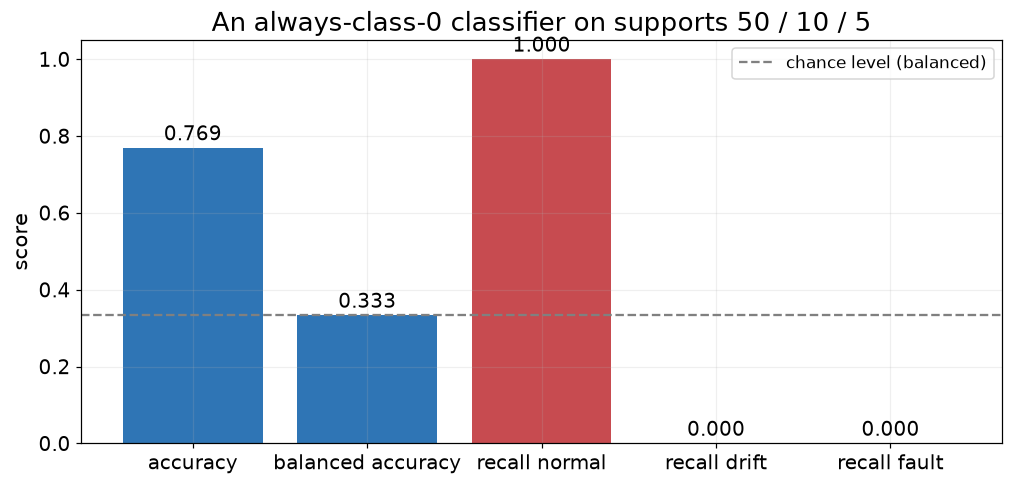

accuracy: 0.7692 | recalls: [1.0, 0.0, 0.0] | balanced accuracy: 0.3333


In [15]:
# RUN 13 — Hand-check an always-majority classifier
cm_majority = torch.tensor([[50, 0, 0], [10, 0, 0], [5, 0, 0]], dtype=torch.int64)
metrics_majority = class_metrics(cm_majority)
fig, ax = plt.subplots(figsize=(9.4, 4.6))
names = ["accuracy", "balanced accuracy", "recall normal", "recall drift", "recall fault"]
values = [metrics_majority["accuracy"].item(), metrics_majority["balanced_accuracy"].item(),
          *metrics_majority["recall"].tolist()]
bars = ax.bar(names, values, color=[COLORS[0], COLORS[0], COLORS[1], COLORS[2], "#7A7A7A"])
ax.axhline(1 / 3, color="gray", ls="--", label="chance level (balanced)")
ax.set(ylabel="score", ylim=(0, 1.05),
       title="An always-class-0 classifier on supports 50 / 10 / 5")
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center")
ax.legend(loc="upper right")
finish("08_imbalance_metrics")

print("accuracy:", round(metrics_majority["accuracy"].item(), 4),
      "| recalls:", [round(v, 4) for v in metrics_majority["recall"].tolist()],
      "| balanced accuracy:", round(metrics_majority["balanced_accuracy"].item(), 4))
assert abs(metrics_majority["accuracy"].item() - 50 / 65) < 1e-12
assert abs(metrics_majority["balanced_accuracy"].item() - 1 / 3) < 1e-12

## 13. Freeze the decision and evaluate once

Scaling, weights, checkpoint, and decision rule are now frozen. The test
split is opened exactly once. Its 90 rows are independent synthetic draws
from the same generator; the score describes that generator, not other
machines, sessions, or operating conditions. A held-out score is evidence
only for the population it samples.

**QUESTION BEFORE RUNNING:** Which choices must be fixed before the test labels
are read? What population does this test score actually describe?

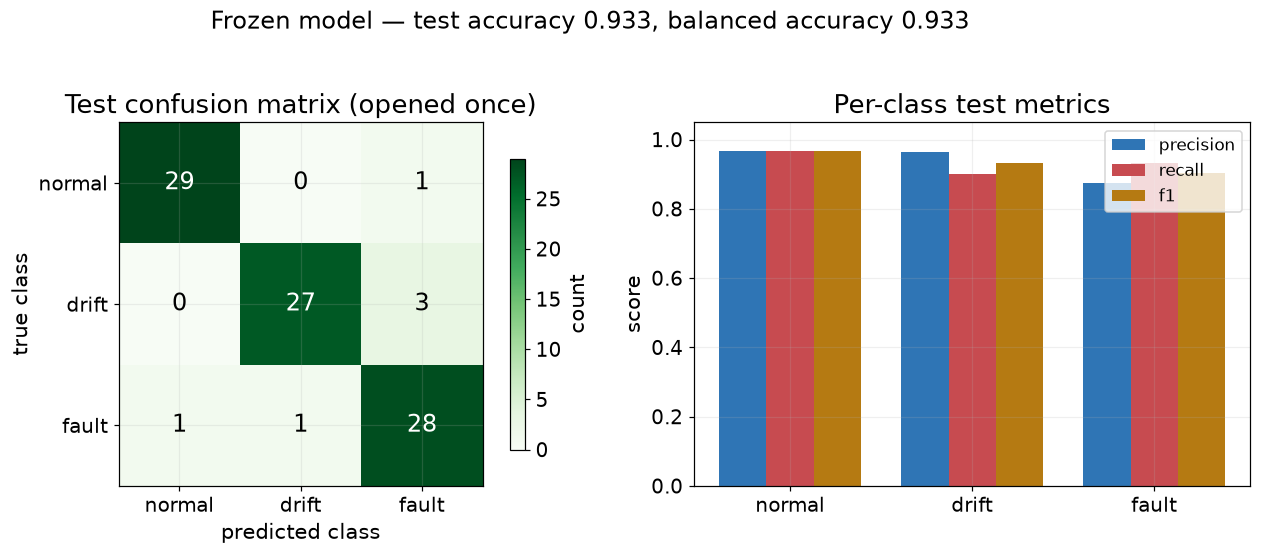

test mean cross-entropy: 0.1721
test accuracy: 0.9333 | balanced accuracy: 0.9333 | macro F1: 0.9336
test confusion matrix:
 [[29  0  1]
 [ 0 27  3]
 [ 1  1 28]]
Test opened once. Next experiment would begin a new development cycle.


In [16]:
# RUN 14 — Final held-out test report
X_test = (_X_test_raw - train_mean) / train_std
y_test = _y_test
with torch.no_grad():
    test_logits = model(X_test)
    test_ce = criterion(test_logits, y_test).item()
    test_pred = test_logits.argmax(1)
cm_test = confusion_matrix(y_test, test_pred)
metrics_test = class_metrics(cm_test)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
image = axes[0].imshow(cm_test.numpy(), cmap="Greens")
for i in range(3):
    for j in range(3):
        color = "white" if cm_test[i, j] > cm_test.max() * 0.55 else "black"
        axes[0].text(j, i, int(cm_test[i, j]), ha="center", va="center", fontsize=16, color=color)
axes[0].set(xticks=range(3), yticks=range(3), xticklabels=CLASSES, yticklabels=CLASSES,
            xlabel="predicted class", ylabel="true class",
            title="Test confusion matrix (opened once)")
fig.colorbar(image, ax=axes[0], shrink=0.8, label="count")
width = 0.26
positions = np.arange(3)
for offset, metric, color in zip((-width, 0.0, width),
                                 ("precision", "recall", "f1"), COLORS):
    axes[1].bar(positions + offset, metrics_test[metric].tolist(), width,
                label=metric, color=color)
axes[1].set(xticks=positions, xticklabels=CLASSES, ylabel="score", ylim=(0, 1.05),
            title="Per-class test metrics")
axes[1].legend()
fig.suptitle(f"Frozen model — test accuracy {metrics_test['accuracy'].item():.3f}, "
             f"balanced accuracy {metrics_test['balanced_accuracy'].item():.3f}", y=1.03)
finish("09_test_report")

print("test mean cross-entropy:", round(test_ce, 4))
print("test accuracy:", round(metrics_test["accuracy"].item(), 4),
      "| balanced accuracy:", round(metrics_test["balanced_accuracy"].item(), 4),
      "| macro F1:", round(metrics_test["macro_f1"].item(), 4))
print("test confusion matrix:\n", cm_test.numpy())
assert cm_test.sum().item() == 90
assert 0.85 <= metrics_test["accuracy"].item() <= 0.98
print("Test opened once. Next experiment would begin a new development cycle.")

## Reserve — what a probability does and does not say

**BOARD:** Softmax probabilities are shaped by the **temperature** `T` used
to scale the logits: `softmax(o/T)`. For any `T>0`, the decision is
unchanged, but confidence and cross-entropy change. A probability is a
model output, not automatically a calibrated frequency. Calibration must be
checked against outcomes, usually on held-out data.

**QUESTION BEFORE RUNNING:** If we divide every test logit by `T=2`, does the
predicted class change? Does the mean confidence? Does the test accuracy?

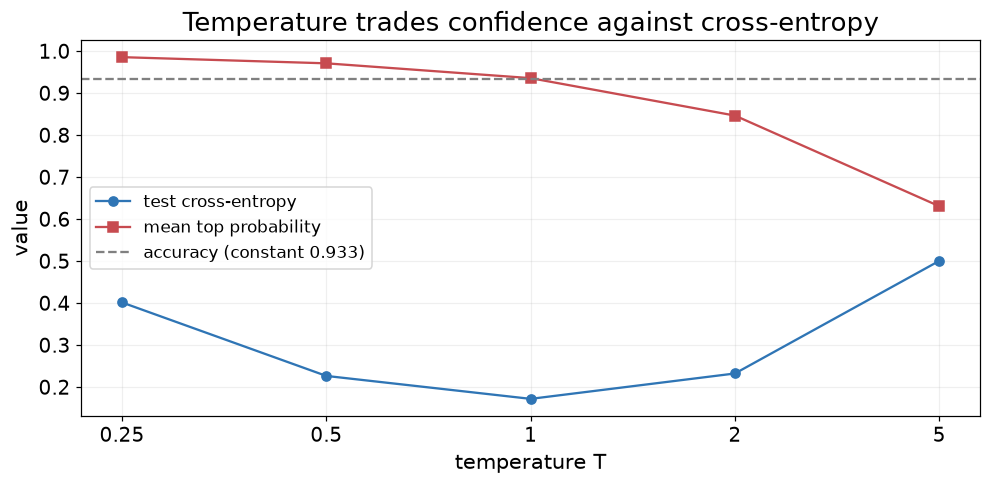

T= 0.25 | CE=0.4016 | mean confidence=0.9858 | accuracy=0.9333
T=  0.5 | CE=0.2266 | mean confidence=0.9711 | accuracy=0.9333
T=    1 | CE=0.1721 | mean confidence=0.9358 | accuracy=0.9333
T=    2 | CE=0.2325 | mean confidence=0.8466 | accuracy=0.9333
T=    5 | CE=0.5006 | mean confidence=0.6308 | accuracy=0.9333
Accuracy never changes; probabilities are not calibrated by construction.


In [17]:
# RUN 15 — Reserve: temperature changes confidence, not decisions
temperatures = torch.tensor([0.25, 0.5, 1.0, 2.0, 5.0], dtype=DTYPE)
rows = []
for temperature in temperatures:
    scaled = test_logits / temperature
    ce = criterion(scaled, y_test).item()
    confidence = torch.softmax(scaled, dim=1).max(dim=1).values.mean().item()
    accuracy = (scaled.argmax(1) == y_test).to(DTYPE).mean().item()
    rows.append((temperature.item(), ce, confidence, accuracy))
rows = np.asarray(rows)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
positions_t = np.arange(len(rows))
ax.plot(positions_t, rows[:, 1], "o-", label="test cross-entropy", color=COLORS[0])
ax.plot(positions_t, rows[:, 2], "s-", label="mean top probability", color=COLORS[1])
ax.axhline(rows[0, 3], color="gray", ls="--",
           label=f"accuracy (constant {rows[0, 3]:.3f})")
ax.set(xlabel="temperature T", ylabel="value",
       title="Temperature trades confidence against cross-entropy")
ax.set_xticks(positions_t, [f"{value:g}" for value in rows[:, 0]])
ax.legend()
finish("10_temperature_confidence")

for temperature, ce, confidence, accuracy in rows:
    print(f"T={temperature:>5g} | CE={ce:.4f} | mean confidence={confidence:.4f} | accuracy={accuracy:.4f}")
assert np.allclose(rows[:, 3], rows[0, 3])
print("Accuracy never changes; probabilities are not calibrated by construction.")

## Exit ticket and reading

Answer without rerunning the notebook:

1. Given logits `[2, 1, −1]` and true class 1, name the prediction and write
   the stable cross-entropy expression.
2. Why must raw logits, not softmax probabilities, be passed to
   `nn.CrossEntropyLoss`?
3. A model has high accuracy but zero recall for a rare fault class. Name a
   metric that reveals this.
4. State the jobs of the training, validation, and test splits.

**Reading:** [Dive into Deep Learning, Chapter 4, Sections 4.1–4.5](https://d2l.ai/chapter_linear-classification/index.html).
Prepare for Lecture 5: perceptrons, nonlinear activations, XOR, and
multilayer perceptrons — what can an affine classifier **not** represent?